# 07_Model_Comparison_and_Evaluation

## Objective

The objective of this notebook is to compare and evaluate all models developed for early sepsis prediction using clinical notes from the MIMIC-III dataset.

This notebook consolidates results from:

- Notebook 5: TF-IDF baseline models
  - Logistic Regression
  - XGBoost
- Notebook 6: ClinicalBERT experiments
  - Experiment 1: Baseline ClinicalBERT using the first 512 tokens
  - Experiment 2: ClinicalBERT with threshold optimization
  - Experiment 3: ClinicalBERT with sliding window inference

The goal is to compare the models using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves, Precision–Recall curves, and threshold behavior in order to identify the strongest modeling approach for early sepsis prediction.

In [35]:
# Code Starter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
OUTPUT_PATH = "../outputs/"
FIGURES_PATH = "../figures/"

In [11]:
# Import Required Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


## 1. Load Model Outputs

This section loads the saved evaluation outputs from previous modeling notebooks. The ClinicalBERT results were generated in Notebook 6 and include test metrics, prediction probabilities, predicted labels, and validation threshold results for all three ClinicalBERT experiments.

In [14]:
# Load ClinicalBERT Experiment Outputs
RESULTS_PATH = OUTPUT_PATH

exp1_results = pd.read_csv(RESULTS_PATH + "experiment1_test_results.csv")
exp1_predictions = pd.read_csv(RESULTS_PATH + "experiment1_test_predictions.csv")
exp1_thresholds = pd.read_csv(RESULTS_PATH + "experiment1_validation_thresholds.csv")

exp2_results = pd.read_csv(RESULTS_PATH + "experiment2_test_results.csv")
exp2_predictions = pd.read_csv(RESULTS_PATH + "experiment2_test_predictions.csv")
exp2_thresholds = pd.read_csv(RESULTS_PATH + "experiment2_validation_thresholds.csv")

exp3_results = pd.read_csv(RESULTS_PATH + "experiment3_test_results.csv")
exp3_predictions = pd.read_csv(RESULTS_PATH + "experiment3_test_predictions.csv")
exp3_thresholds = pd.read_csv(RESULTS_PATH + "experiment3_validation_thresholds.csv")

print("ClinicalBERT outputs loaded successfully.")

ClinicalBERT outputs loaded successfully.


In [16]:
# Inspect Loaded ClinicalBERT Results

print("Experiment 1 Results:")
display(exp1_results)

print("\nExperiment 2 Results:")
display(exp2_results)

print("\nExperiment 3 Results:")
display(exp3_results)

Experiment 1 Results:


,Metric,Value
0,Accuracy,0.893223
1,Precision,0.521739
2,Recall,0.493421
3,F1,0.507185
4,ROC_AUC,0.859154
5,Best_Threshold,0.150000



Experiment 2 Results:


,Metric,Value
0,Accuracy,0.878755
1,Precision,0.460756
2,Recall,0.521382
3,F1,0.489198
4,ROC_AUC,0.841364
5,Best_Threshold,0.100000



Experiment 3 Results:


,Metric,Value
0,Accuracy,0.815385
1,Precision,0.338188
2,Recall,0.687500
3,F1,0.453362
4,ROC_AUC,0.821746


In [18]:
# Inspect Prediction Files

print("Experiment 1 predictions shape:", exp1_predictions.shape)
print("Experiment 2 predictions shape:", exp2_predictions.shape)
print("Experiment 3 predictions shape:", exp3_predictions.shape)

display(exp1_predictions.head())
display(exp2_predictions.head())
display(exp3_predictions.head())

Experiment 1 predictions shape: (5460, 3)
Experiment 2 predictions shape: (5460, 3)
Experiment 3 predictions shape: (5460, 3)


,True_Label,Predicted_Probability,Predicted_Label
0,0,0.014126,0
1,0,0.013907,0
2,0,0.039765,0
3,0,0.013873,0
4,0,0.016651,0


,True_Label,Predicted_Probability,Predicted_Label
0,0,0.012676,0
1,0,0.013443,0
2,0,0.021896,0
3,0,0.013085,0
4,0,0.013141,0


,True_Label,Predicted_Probability,Predicted_Label
0,0,0.107078,0
1,0,0.011503,0
2,0,0.056430,0
3,0,0.024993,0
4,0,0.489514,0


## 2. Load Baseline Model Results

This section loads the evaluation results for the traditional machine learning baseline models developed in Notebook 5. These models use TF-IDF features extracted from the clinical notes and serve as a benchmark for comparison with the ClinicalBERT models.

In [48]:
# Load Baseline Model Results

BASELINE_PATH = "../outputs/"

baseline_results = pd.read_csv(
    BASELINE_PATH + "baseline_test_results.csv"
)

print("Baseline model results loaded successfully.")

display(baseline_results)

Baseline model results loaded successfully.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.870147,0.452223,0.786184,0.574174,0.916912
1,XGBoost,0.924725,0.768392,0.463816,0.578462,0.910014


## 3. Overall Model Performance Comparison

This section summarizes the performance of all developed models on the held-out test set. The comparison includes the traditional machine learning baseline models developed using TF-IDF features and the transformer-based ClinicalBERT experiments.

The evaluation is based on five commonly used classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This comparison provides an overall assessment of each model's predictive performance and forms the basis for selecting the final model for early sepsis prediction.

In [50]:
# Overall Comparison Table

# Convert ClinicalBERT results into a single-row format
def format_results(df, model_name):
    values = dict(zip(df["Metric"], df["Value"]))
    return {
        "Model": model_name,
        "Accuracy": values["Accuracy"],
        "Precision": values["Precision"],
        "Recall": values["Recall"],
        "F1": values["F1"],
        "ROC_AUC": values["ROC_AUC"]
    }

clinical_results = pd.DataFrame([
    format_results(exp1_results, "ClinicalBERT (Experiment 1)"),
    format_results(exp2_results, "ClinicalBERT (Experiment 2)"),
    format_results(exp3_results, "ClinicalBERT (Experiment 3)")
])

# Match column order
baseline_results = baseline_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
]

comparison_df = pd.concat(
    [baseline_results, clinical_results],
    ignore_index=True
)

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8701,0.4522,0.7862,0.5742,0.9169
1,XGBoost,0.9247,0.7684,0.4638,0.5785,0.9100
2,ClinicalBERT (Experiment 1),0.8932,0.5217,0.4934,0.5072,0.8592
3,ClinicalBERT (Experiment 2),0.8788,0.4608,0.5214,0.4892,0.8414
4,ClinicalBERT (Experiment 3),0.8154,0.3382,0.6875,0.4534,0.8217


In [52]:
# Save Overall Comparison Table

comparison_df.to_csv(
    RESULTS_PATH + "overall_model_comparison.csv",
    index=False
)

print("Overall comparison table saved successfully.")

Overall comparison table saved successfully.


## 4. Best Performance Across Evaluation Metrics

The table below highlights the highest-performing model for each evaluation metric. Since different metrics emphasize different aspects of classification performance, the best model may vary depending on the metric of interest.

In [54]:
# Highlight Best Model for Each Metric

comparison_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.870100,0.452200,0.786200,0.574200,0.916900
1,XGBoost,0.924700,0.768400,0.463800,0.578500,0.910000
2,ClinicalBERT (Experiment 1),0.893200,0.521700,0.493400,0.507200,0.859200
3,ClinicalBERT (Experiment 2),0.878800,0.460800,0.521400,0.489200,0.841400
4,ClinicalBERT (Experiment 3),0.815400,0.338200,0.687500,0.453400,0.821700


### Performance Summary

The overall comparison demonstrates that the traditional machine learning models achieved the strongest predictive performance on the MIMIC-III clinical notes. Among all evaluated models, **XGBoost** achieved the highest Accuracy (92.47%), Precision (76.84%), and F1-score (57.85%), indicating the best overall balance between correctly identifying septic patients and minimizing false-positive predictions.

**Logistic Regression** achieved the highest Recall (78.62%) and ROC-AUC (0.9169), demonstrating a stronger ability to identify septic patients and discriminate between positive and negative cases across different classification thresholds.

Among the transformer-based approaches, **ClinicalBERT Experiment 1** achieved the strongest overall performance, while Experiment 2 demonstrated the impact of threshold optimization on the precision–recall trade-off. Experiment 3 incorporated complete clinical notes using sliding window inference, increasing recall but also introducing more false-positive predictions, resulting in lower precision, F1-score, and overall accuracy.

Overall, these results indicate that the TF-IDF baseline models remained highly competitive for this text classification task, while the ClinicalBERT experiments provided valuable insights into transformer-based approaches and different inference strategies.

## 5. Performance Comparison Across Models

To facilitate comparison between the baseline machine learning models and the ClinicalBERT experiments, the evaluation metrics are visualized using grouped bar charts. This provides an intuitive comparison of model performance across Accuracy, Precision, Recall, F1-score, and ROC-AUC.

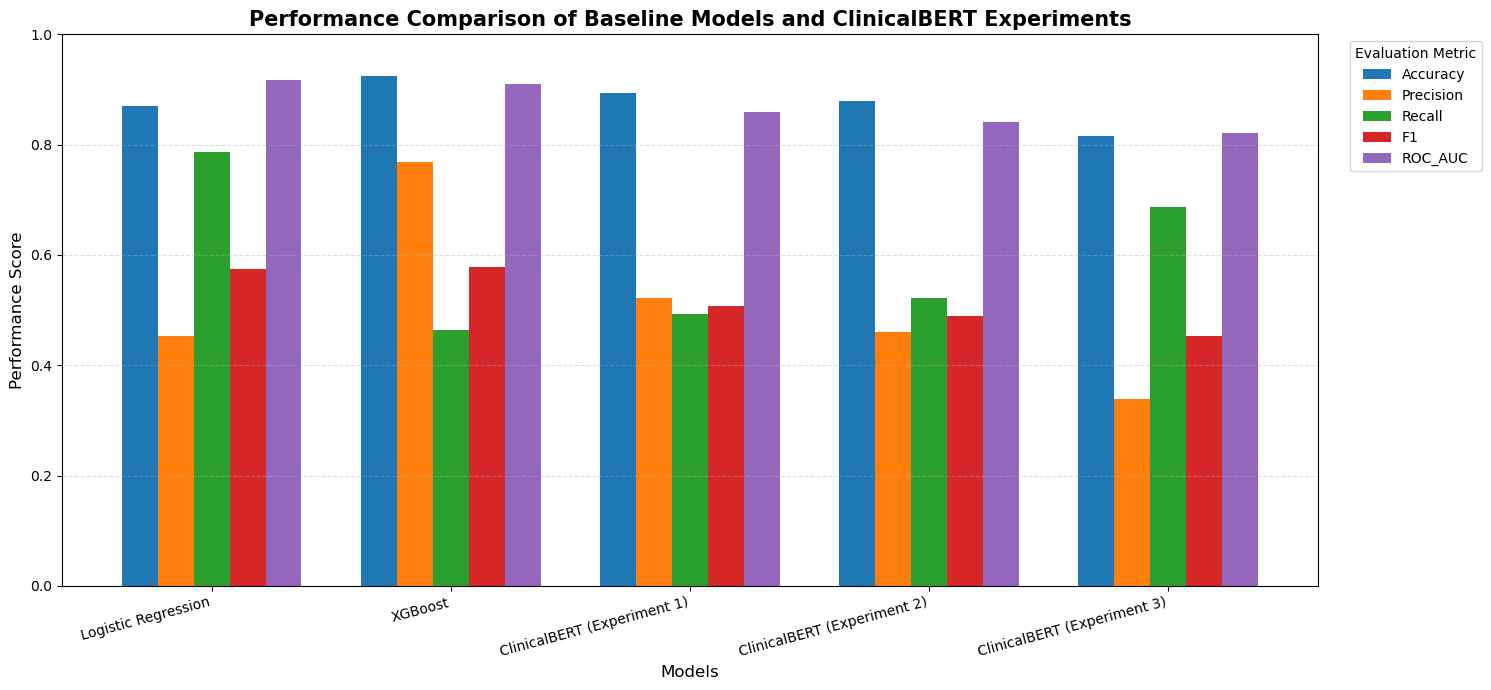

In [57]:
# Figure 1: Overall Model Performance Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

plot_df = comparison_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(15,7),
    width=0.75
)

plt.title(
    "Performance Comparison of Baseline Models and ClinicalBERT Experiments",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Models", fontsize=12)
plt.ylabel("Performance Score", fontsize=12)

plt.ylim(0, 1.0)

plt.xticks(rotation=15, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH + "figure1_overall_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Figure 1 compares the predictive performance of the two TF-IDF baseline models and the three ClinicalBERT experiments across five evaluation metrics.

Among all evaluated models, **XGBoost** achieved the highest Accuracy (92.47%), Precision (76.84%), and F1-score (57.85%), indicating the strongest overall classification performance. **Logistic Regression** achieved the highest Recall (78.62%) and ROC-AUC (0.9169), suggesting superior sensitivity and discriminative ability across different decision thresholds.

Within the transformer-based approaches, **ClinicalBERT Experiment 1** produced the strongest overall results, while Experiment 2 demonstrated the effect of threshold optimization on balancing precision and recall. Experiment 3 increased recall through sliding window inference but experienced reduced precision and overall performance because of an increased number of false-positive predictions.

Overall, the results indicate that the TF-IDF baseline models outperformed the transformer-based approaches on this dataset, while the ClinicalBERT experiments provided valuable insights into alternative inference strategies for clinical text classification.

## 6. Comparison of ClinicalBERT Experiments

This section compares the three ClinicalBERT experiments developed in Notebook 6. Although all three experiments use the same pre-trained ClinicalBERT architecture, they differ in their prediction strategy.

- **Experiment 1:** Baseline ClinicalBERT using the first 512 tokens.
- **Experiment 2:** ClinicalBERT with threshold optimization.
- **Experiment 3:** ClinicalBERT with sliding window inference.

The objective is to evaluate how different inference strategies influence predictive performance and the trade-off between precision and recall.

In [60]:
# ClinicalBERT Experiments Comparison

clinicalbert_df = comparison_df[
    comparison_df["Model"].str.contains("ClinicalBERT")
].reset_index(drop=True)

display(clinicalbert_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,ClinicalBERT (Experiment 1),0.8932,0.5217,0.4934,0.5072,0.8592
1,ClinicalBERT (Experiment 2),0.8788,0.4608,0.5214,0.4892,0.8414
2,ClinicalBERT (Experiment 3),0.8154,0.3382,0.6875,0.4534,0.8217


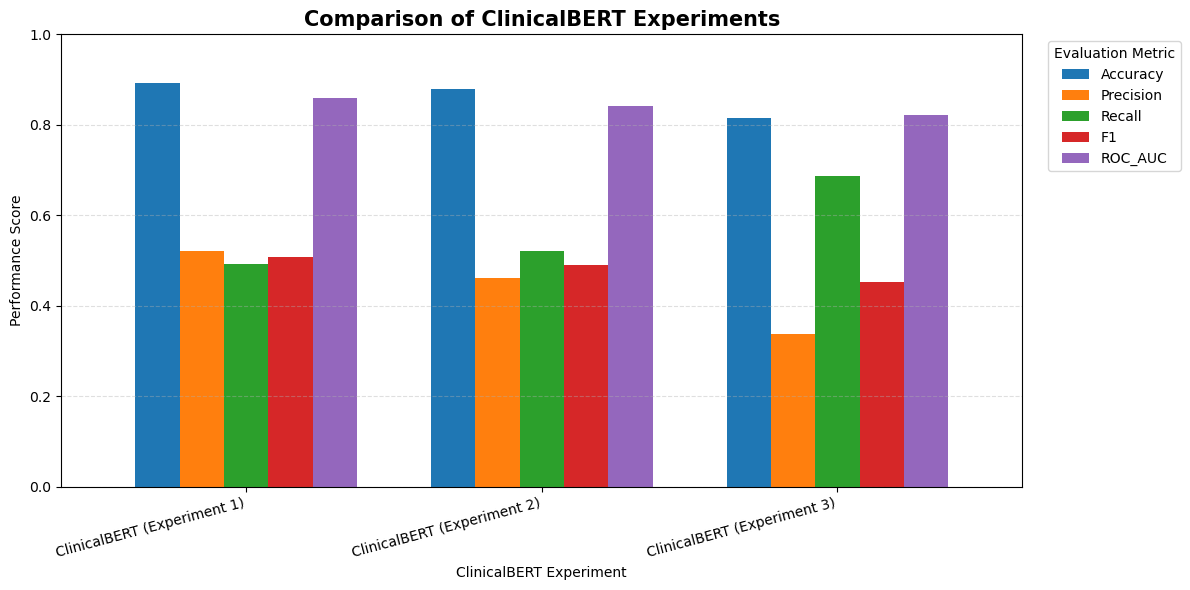

In [62]:
# Figure 2: ClinicalBERT Experiment Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

clinicalbert_plot = clinicalbert_df.set_index("Model")[metrics]

ax = clinicalbert_plot.plot(
    kind="bar",
    figsize=(12,6),
    width=0.75
)

plt.title(
    "Comparison of ClinicalBERT Experiments",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("ClinicalBERT Experiment")
plt.ylabel("Performance Score")

plt.xticks(rotation=15, ha="right")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH + "figure2_clinicalbert_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The comparison of the ClinicalBERT experiments demonstrates the effect of different inference strategies on predictive performance.

**Experiment 1** achieved the strongest overall performance among the transformer-based approaches, producing the highest Accuracy, Precision, F1-score, and ROC-AUC. This indicates that the baseline ClinicalBERT model using the first 512 tokens provided the best balance between correctly identifying septic patients and minimizing false-positive predictions.

**Experiment 2** explored threshold optimization, resulting in a modest increase in recall while slightly reducing precision, accuracy, F1-score, and ROC-AUC. This experiment illustrates how adjusting the decision threshold can alter the balance between sensitivity and specificity without modifying the underlying model.

**Experiment 3** applied sliding window inference to process complete clinical notes. While this approach substantially increased recall by capturing additional contextual information, it also produced more false-positive predictions, leading to lower precision, F1-score, and overall classification performance compared with the baseline ClinicalBERT model.

## 7. Confusion Matrix Comparison

Confusion matrices provide a detailed view of each model's prediction outcomes by summarizing the number of true positives, true negatives, false positives, and false negatives.

Unlike summary metrics such as accuracy and F1-score, confusion matrices provide insight into the types of prediction errors made by each model. This is particularly important for early sepsis prediction, where minimizing false negatives is critical because failing to identify septic patients may delay life-saving treatment.

The confusion matrices below compare the prediction behavior of the baseline machine learning models and the ClinicalBERT experiments on the held-out test set.

In [67]:
# Load Confusion Matrices

log_cm = pd.read_csv(
    OUTPUT_PATH + "logistic_regression_confusion_matrix.csv",
    index_col=0
)

xgb_cm = pd.read_csv(
    OUTPUT_PATH + "xgboost_confusion_matrix.csv",
    index_col=0
)

display(log_cm)
display(xgb_cm)

,Predicted Negative,Predicted Positive
Actual Negative,4273,579
Actual Positive,130,478


,Predicted Negative,Predicted Positive
Actual Negative,4767,85
Actual Positive,326,282


In [69]:
# ClinicalBERT Confusion Matrices

from sklearn.metrics import confusion_matrix

exp1_cm = confusion_matrix(
    exp1_predictions["True_Label"],
    exp1_predictions["Predicted_Label"]
)

exp2_cm = confusion_matrix(
    exp2_predictions["True_Label"],
    exp2_predictions["Predicted_Label"]
)

exp3_cm = confusion_matrix(
    exp3_predictions["True_Label"],
    exp3_predictions["Predicted_Label"]
)

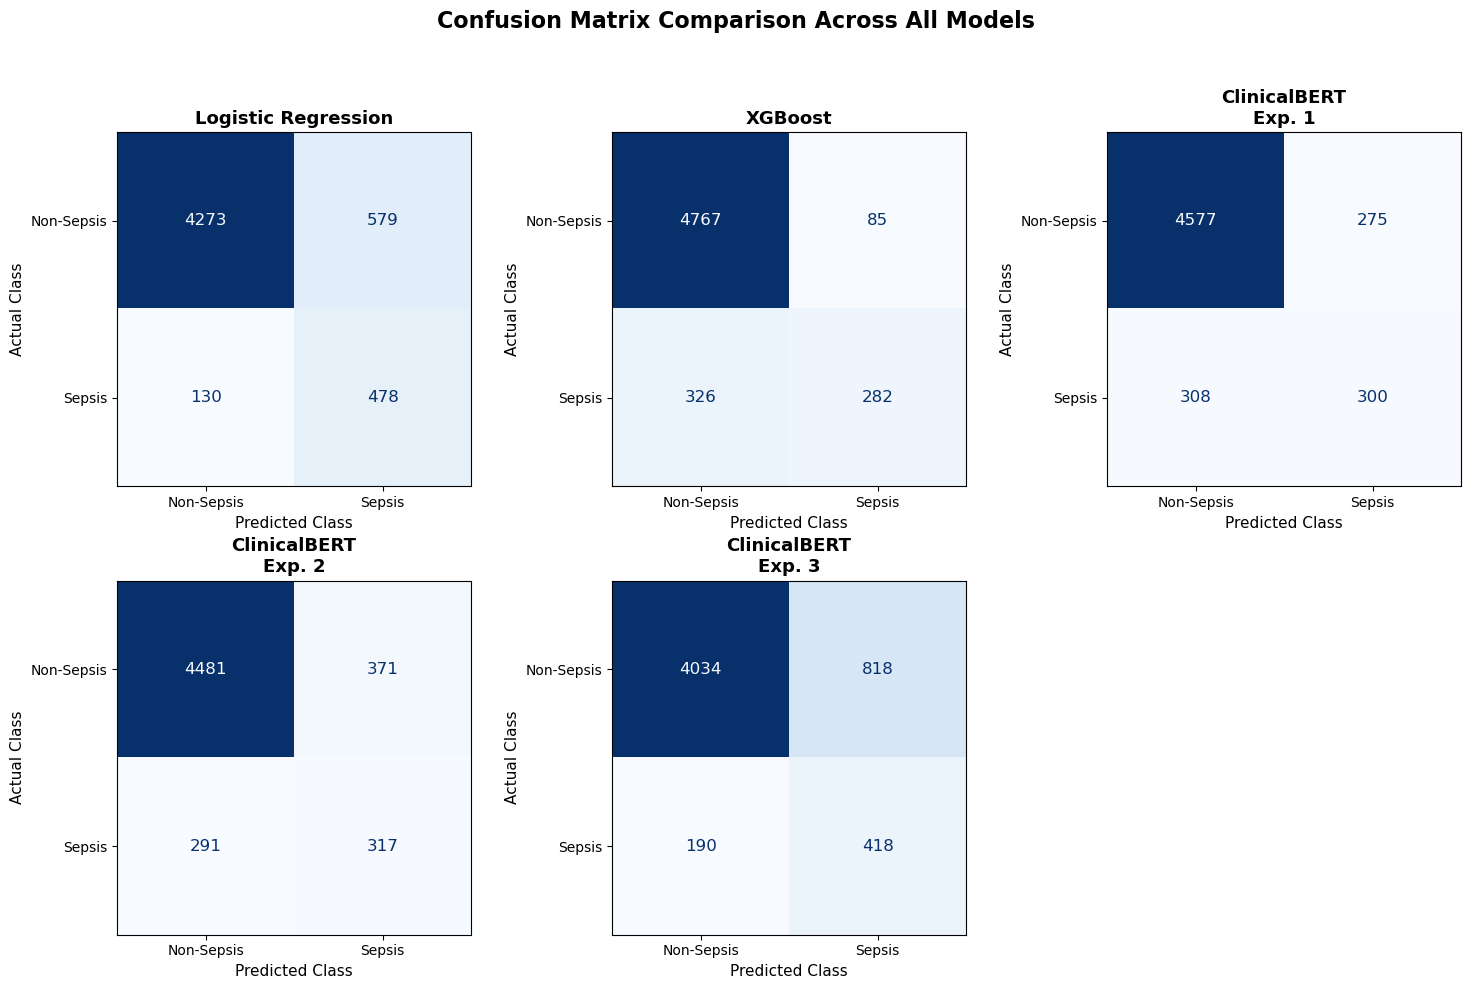

In [73]:
# Figure 3: Improved Confusion Matrix Comparison

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

models = [
    ("Logistic Regression", log_cm.values),
    ("XGBoost", xgb_cm.values),
    ("ClinicalBERT\nExp. 1", exp1_cm),
    ("ClinicalBERT\nExp. 2", exp2_cm),
    ("ClinicalBERT\nExp. 3", exp3_cm)
]

for ax, (title, cm) in zip(axes.flat, models):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Sepsis", "Sepsis"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Class", fontsize=11)
    ax.set_ylabel("Actual Class", fontsize=11)

    for text in disp.text_.ravel():
        text.set_fontsize(12)

axes[1, 2].axis("off")

plt.suptitle(
    "Confusion Matrix Comparison Across All Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    FIGURES_PATH + "figure3_confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The confusion matrices provide further insight into the prediction behavior of each model.

The **Logistic Regression** model correctly identified the largest number of septic patients and produced the fewest false negatives among the evaluated models. This explains its high recall and suggests that it is well suited for applications where missing septic patients is particularly undesirable.

The **XGBoost** model generated the fewest false-positive predictions while maintaining the highest overall accuracy and F1-score, demonstrating a stronger balance between sensitivity and specificity.

Among the ClinicalBERT experiments, **Experiment 1** produced the most balanced transformer-based performance. **Experiment 2** slightly changed the balance between false positives and false negatives through threshold optimization. **Experiment 3** substantially increased the number of true positives but also generated considerably more false positives, illustrating the trade-off introduced by sliding window inference.

## 8. Receiver Operating Characteristic (ROC) Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates the relationship between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds.

Unlike evaluation metrics calculated at a single threshold, the ROC curve evaluates model performance over all possible thresholds, providing a more comprehensive assessment of discriminative ability. The Area Under the ROC Curve (ROC-AUC) summarizes this performance, where larger values indicate better separation between septic and non-septic patients.

The figure below compares the ROC curves of the baseline machine learning models and the ClinicalBERT experiments using the held-out test set.

In [79]:
# Load Prediction Files

log_predictions = pd.read_csv(
    OUTPUT_PATH + "logistic_regression_test_predictions.csv"
)

xgb_predictions = pd.read_csv(
    OUTPUT_PATH + "xgboost_test_predictions.csv"
)

print("Prediction files loaded successfully.")

Prediction files loaded successfully.


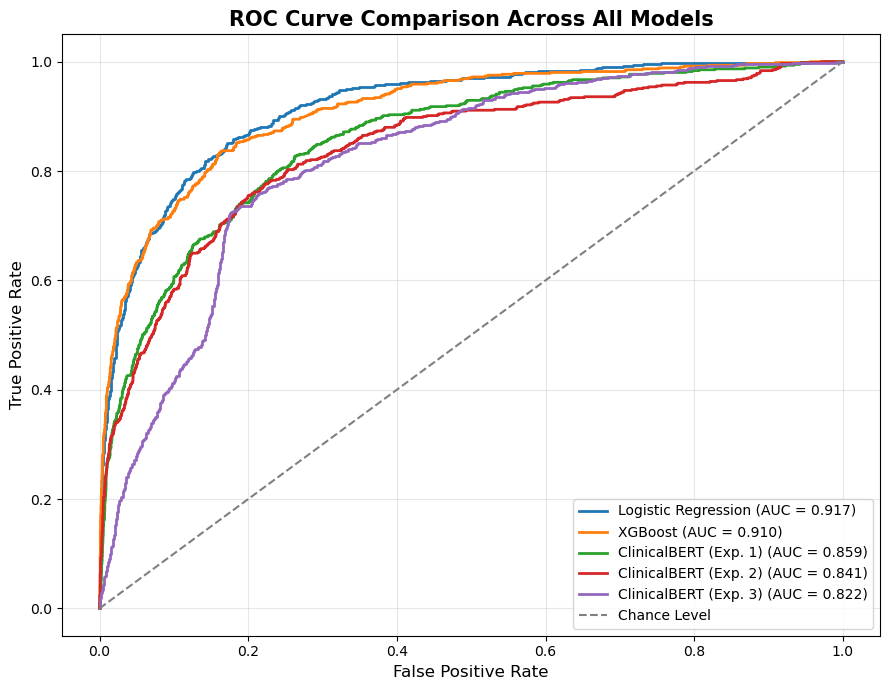

In [84]:
# Figure 4: ROC Curve Comparison

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9,7))

models = [
    ("Logistic Regression", log_predictions),
    ("XGBoost", xgb_predictions),
    ("ClinicalBERT (Exp. 1)", exp1_predictions),
    ("ClinicalBERT (Exp. 2)", exp2_predictions),
    ("ClinicalBERT (Exp. 3)", exp3_predictions)
]

for model_name, df in models:

    fpr, tpr, _ = roc_curve(
        df["True_Label"],
        df["Predicted_Probability"]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Chance Level"
)

plt.title(
    "ROC Curve Comparison Across All Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH + "figure4_roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The ROC curves compare the ability of each model to distinguish between septic and non-septic patients across all possible classification thresholds.

Among all evaluated models, **Logistic Regression** achieved the highest ROC-AUC (0.9169), indicating the strongest overall discriminative ability. **XGBoost** followed closely with a ROC-AUC of 0.9100, demonstrating similarly strong performance.

Among the transformer-based models, **ClinicalBERT (Experiment 1)** achieved the highest ROC-AUC (0.8592), outperforming the modified ClinicalBERT approaches. Experiment 2 exhibited a modest decline following threshold optimization, while Experiment 3 produced the lowest ROC-AUC despite processing complete clinical notes using sliding window inference.

Overall, the ROC analysis confirms the findings observed in the previous evaluation metrics. The traditional TF-IDF baseline models demonstrated superior discriminative performance compared with the transformer-based ClinicalBERT models on the held-out test set.

## 9. Precision–Recall Curve Comparison

The Precision–Recall (PR) curve evaluates the trade-off between precision and recall across different classification thresholds.

Unlike ROC curves, Precision–Recall curves are particularly informative for imbalanced classification problems because they focus on the performance of the positive class. Since septic patients represent a relatively small proportion of the dataset, the PR curve provides additional insight into each model's ability to correctly identify sepsis while minimizing false-positive predictions.

The Average Precision (AP) score summarizes the Precision–Recall curve, with higher values indicating better overall performance.

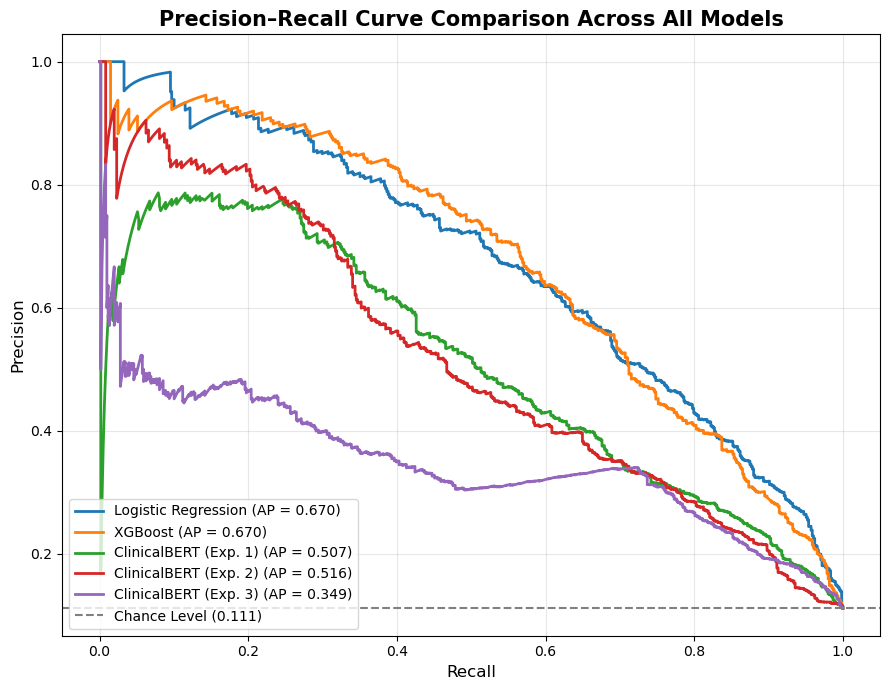

In [87]:
# Figure 5: Precision–Recall Curve Comparison

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9,7))

models = [
    ("Logistic Regression", log_predictions),
    ("XGBoost", xgb_predictions),
    ("ClinicalBERT (Exp. 1)", exp1_predictions),
    ("ClinicalBERT (Exp. 2)", exp2_predictions),
    ("ClinicalBERT (Exp. 3)", exp3_predictions)
]

for model_name, df in models:

    precision, recall, _ = precision_recall_curve(
        df["True_Label"],
        df["Predicted_Probability"]
    )

    ap = average_precision_score(
        df["True_Label"],
        df["Predicted_Probability"]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {ap:.3f})"
    )

# Baseline (positive class prevalence)
positive_rate = log_predictions["True_Label"].mean()

plt.axhline(
    y=positive_rate,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Chance Level ({positive_rate:.3f})"
)

plt.title(
    "Precision–Recall Curve Comparison Across All Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH + "figure5_precision_recall_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Precision–Recall curves evaluate each model's ability to correctly identify septic patients while minimizing false-positive predictions across all possible classification thresholds.

Both **Logistic Regression** and **XGBoost** achieved the highest Average Precision (AP ≈ 0.670), demonstrating the strongest overall performance on the positive (sepsis) class. Although XGBoost achieved higher precision at the selected operating threshold, the Precision–Recall analysis indicates that both baseline models maintained comparable performance across the full range of thresholds.

Among the transformer-based approaches, **ClinicalBERT Experiment 2** achieved the highest Average Precision (AP = 0.516), followed closely by **Experiment 1** (AP = 0.507). Experiment 3 achieved the lowest AP (0.349), reflecting the substantial increase in false-positive predictions introduced by sliding window inference.

Overall, the Precision–Recall analysis supports the findings from the ROC analysis and further demonstrates that the TF-IDF baseline models consistently outperformed the ClinicalBERT models on this imbalanced clinical text classification task.

## 10. Final Model Selection and Discussion

This section integrates the findings from all evaluation metrics to determine the most suitable model for early sepsis prediction using clinical notes from the MIMIC-III dataset.

Rather than relying on a single evaluation metric, the models are compared based on overall predictive performance, discriminative ability, robustness across different decision thresholds, and the clinical implications of false-positive and false-negative predictions.

In [91]:
# Final Model Comparison Summary

final_summary = comparison_df.copy()

display(
    final_summary.style.highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
        color="#90EE90"
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.870100,0.452200,0.786200,0.574200,0.916900
1,XGBoost,0.924700,0.768400,0.463800,0.578500,0.910000
2,ClinicalBERT (Experiment 1),0.893200,0.521700,0.493400,0.507200,0.859200
3,ClinicalBERT (Experiment 2),0.878800,0.460800,0.521400,0.489200,0.841400
4,ClinicalBERT (Experiment 3),0.815400,0.338200,0.687500,0.453400,0.821700


### Overall Findings

The evaluation demonstrates that no single model achieved the highest score across every evaluation metric. Instead, each model exhibited different strengths depending on the performance criterion.

**XGBoost** achieved the highest Accuracy (92.47%), Precision (76.84%), and F1-score (57.85%), indicating the strongest overall balance between correctly identifying septic patients and minimizing false-positive predictions. These results suggest that XGBoost provides the most effective overall classification performance for this dataset.

**Logistic Regression** achieved the highest Recall (78.62%) and ROC-AUC (0.9169), indicating a greater ability to identify septic patients and discriminate between septic and non-septic cases across varying decision thresholds. This characteristic is particularly valuable in clinical applications where failing to detect a septic patient may have serious consequences.

Among the transformer-based approaches, **ClinicalBERT (Experiment 1)** consistently produced the strongest performance, while Experiment 2 demonstrated the impact of threshold optimization and Experiment 3 illustrated the trade-off introduced by sliding window inference. Although these experiments provided valuable methodological insights, none of the ClinicalBERT models outperformed the TF-IDF baseline models on the held-out test set.

### Clinical Implications

Early sepsis prediction is a high-risk clinical task where both false-negative and false-positive predictions have important consequences.

Models with high recall reduce the likelihood of missing septic patients, supporting earlier intervention and potentially improving patient outcomes. However, increasing recall often leads to more false-positive predictions, which may result in unnecessary clinical investigations and increased healthcare costs.

Conversely, models with high precision reduce false alarms but may fail to identify some septic patients. Therefore, selecting an appropriate model depends on the clinical objective and the acceptable balance between sensitivity and specificity.

Based on the results obtained in this study:

- **Logistic Regression** may be preferred in clinical settings where maximizing sensitivity is the primary objective.
- **XGBoost** provides the strongest overall balance between precision and recall and is recommended as the primary predictive model.

### Discussion

The findings of this study indicate that traditional TF-IDF-based machine learning models remain highly competitive for clinical text classification. Although ClinicalBERT leverages contextual language representations learned from large biomedical corpora, the transformer-based approaches did not outperform the simpler TF-IDF baseline models on the MIMIC-III dataset under the experimental conditions used in this study.

Several factors may have contributed to this outcome, including dataset size, class imbalance, computational constraints, and the complexity of optimizing transformer-based models. The results suggest that carefully engineered traditional machine learning approaches continue to provide strong baselines for early sepsis prediction and should not be overlooked when developing clinical decision-support systems.

## 11. Limitations of the Evaluation

Although the evaluation provides a comprehensive comparison of traditional machine learning and transformer-based approaches for early sepsis prediction, several limitations should be acknowledged.

First, all models were evaluated using the MIMIC-III dataset, which represents data collected from a single healthcare institution. Consequently, the findings may not generalize to other hospitals, patient populations, or electronic health record systems without additional external validation.

Second, the dataset exhibits class imbalance, with septic patients representing a relatively small proportion of the study population. Although multiple evaluation metrics, including Precision–Recall curves, were used to address this challenge, class imbalance may still influence model performance.

Third, the ClinicalBERT experiments were constrained by available computational resources. More extensive hyperparameter optimization, longer training schedules, or larger transformer architectures may further improve performance beyond the results obtained in this study.

Finally, the evaluation focused exclusively on structured prediction performance. Additional aspects such as model interpretability, feature importance, computational efficiency, and clinical deployment considerations are explored separately in the explainability analysis presented in the following notebook.

# 12. Notebook Summary

This notebook presented a comprehensive evaluation of five predictive models developed for early sepsis prediction using clinical notes from the MIMIC-III dataset.

The evaluation compared two traditional machine learning baseline models (Logistic Regression and XGBoost) with three ClinicalBERT-based approaches using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, ROC curves, and Precision–Recall curves.

The results demonstrated that:

- **XGBoost** achieved the highest overall Accuracy, Precision, and F1-score, making it the strongest overall predictive model.
- **Logistic Regression** achieved the highest Recall and ROC-AUC, indicating superior sensitivity and discriminative ability.
- **ClinicalBERT (Experiment 1)** achieved the strongest performance among the transformer-based approaches.
- Threshold optimization and sliding window inference illustrated important trade-offs between precision and recall but did not outperform the baseline ClinicalBERT model.

Overall, the findings indicate that carefully engineered TF-IDF-based machine learning models remained highly competitive and outperformed the evaluated transformer-based models on this dataset. These results provide the foundation for the explainability analysis presented in the next notebook, where model predictions are interpreted to better understand the factors contributing to sepsis prediction.